# 🟠 Project 04 - Hard · Medical Insurance Cost Prediction (real CSV from the web)

> **MLCourse · Machine Learning · Linear Regression Projects**

## Business question
An insurer asks: *predict annual medical charges per customer and identify the
segments driving cost.* This is REAL tabular data with a heavily skewed target,
strong interaction effects, and business stakes.

## Dataset
`insurance.csv` - 1,338 real US beneficiaries: age, sex, bmi, children,
smoker, region, charges. Downloaded from a stable GitHub mirror and cached
locally after first pull.

In [1]:
from pathlib import Path
_ML = Path.cwd()
while _ML.name != "02_machine_learning" and _ML != _ML.parent:
    _ML = _ML.parent
_CACHE = _ML / "data" / "insurance.csv"
import os as _os
_os.makedirs(_CACHE.parent, exist_ok=True)
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.request import urlopen

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

URL = ("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/"
       "master/insurance.csv")
CACHE = _CACHE

if os.path.exists(CACHE):
    ins = pd.read_csv(CACHE)
    print("loaded from local cache")
else:
    try:
        ins = pd.read_csv(URL)
        ins.to_csv(CACHE, index=False)          # cache for offline reruns
        print("downloaded & cached")
    except Exception as e:
        print("No internet and no cache:", e)
        raise

print(ins.shape)
display(ins.head())

loaded from local cache
(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. EDA - where does the money go?

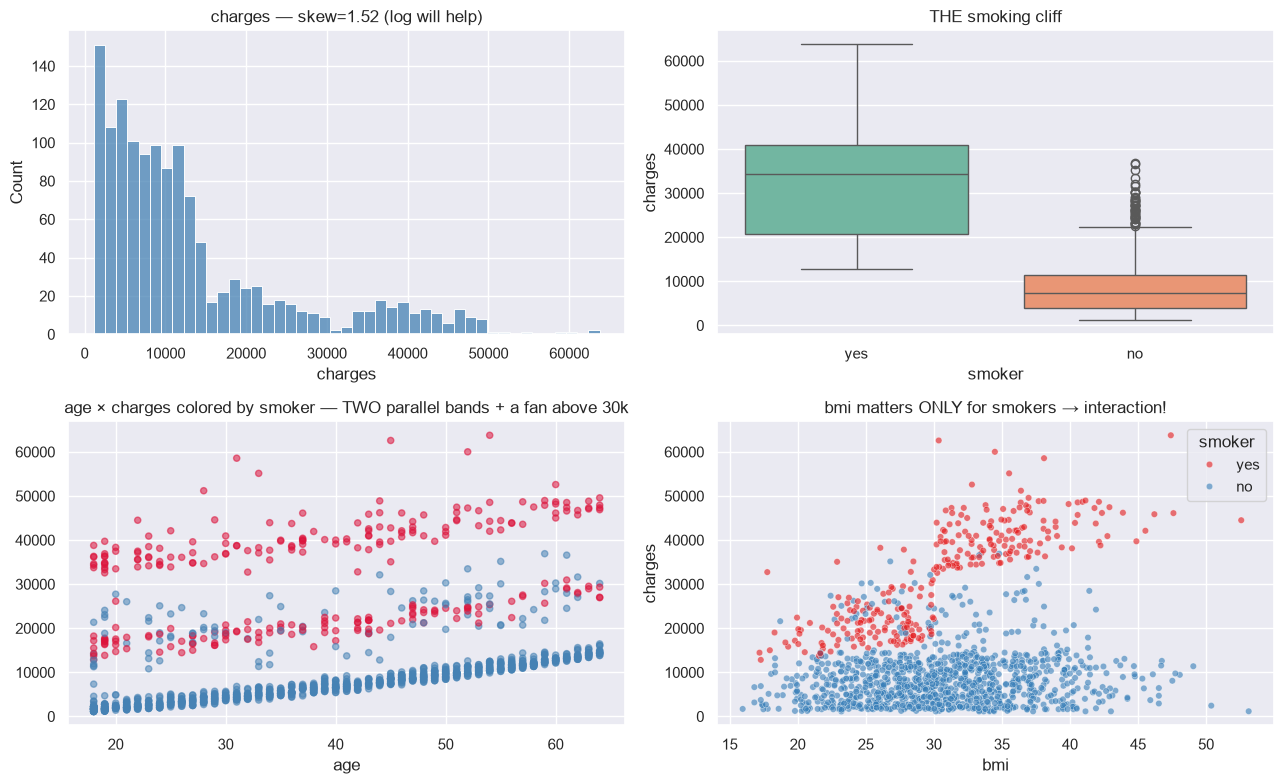

        count     mean
smoker                
no       1064   8434.0
yes       274  32050.0


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(ins["charges"], bins=45, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title(f"charges - skew={ins.charges.skew():.2f} (log will help)")

sns.boxplot(data=ins, x="smoker", y="charges", ax=axes[0, 1],
            palette="Set2", hue="smoker", legend=False)
axes[0, 1].set_title("THE smoking cliff")

axes[1, 0].scatter(ins.age, ins.charges,
                   c=ins.smoker.map({"yes": "crimson", "no": "steelblue"}),
                   alpha=.55, s=20)
axes[1, 0].set_xlabel("age"); axes[1, 0].set_title(
    "age × charges colored by smoker - TWO parallel bands + a fan above 30k")

sns.scatterplot(data=ins, x="bmi", y="charges", hue="smoker",
                palette="Set1", alpha=.6, s=22, ax=axes[1, 1])
axes[1, 1].set_title("bmi matters ONLY for smokers → interaction!")

plt.tight_layout(); plt.show()

print(ins.groupby("smoker")["charges"].agg(["count", "mean"]).round(0))

## 2. Feature engineering - encode AND add the visible interactions

In [3]:
feats = pd.get_dummies(
    ins.drop(columns="charges"),
    columns=["sex", "smoker", "region"],
    drop_first=True,
)

# The scatterplot literally showed multiplicative structure:
feats["smoker_x_bmi"]   = feats["smoker_yes"] * feats["bmi"]
feats["smoker_x_age"]   = feats["smoker_yes"] * feats["age"]
feats["obese_smoker"]   = ((ins.bmi >= 30) & (ins.smoker == "yes")).astype(int)

y_log = np.log1p(ins["charges"])                  # model log-charges
y_raw = ins["charges"].values

X_tr, X_te, ylog_tr, ylog_te, yraw_tr, yraw_te = train_test_split(
    feats.values.astype(float), y_log.values, y_raw,
    test_size=.25, random_state=42)

pipe = Pipeline([("sc", StandardScaler()),
                 ("lr", LinearRegression())]).fit(X_tr, ylog_tr)

pred_log = pipe.predict(X_te)
pred_raw = np.expm1(pred_log)                     # back to dollars

def dollars(y_true_d, y_pred_d):
    return {"R²($)": round(r2_score(y_true_d, y_pred_d), 3),
            "MAE($)": round(mean_absolute_error(y_true_d, y_pred_d), 1),
            "RMSE($)": round(float(np.sqrt(mean_squared_error(y_true_d, y_pred_d))), 1)}

cv_r2_log = cross_val_score(pipe, X_tr, ylog_tr, cv=5, scoring="r2").mean()
display(pd.DataFrame([
    {"model": "LR on log-charges", **dollars(yraw_te, pred_raw),
     "CV R²(log)": round(cv_r2_log, 3)},
]))
print("median absolute error in $:",
      round(float(np.median(np.abs(yraw_te - pred_raw))), 1))

,model,R²($),MAE($),RMSE($),CV R²(log)
0,LR on log-charges,0.843,2453.5,4866.6,0.826


median absolute error in $: 731.5


## 3. Coefficients → business language

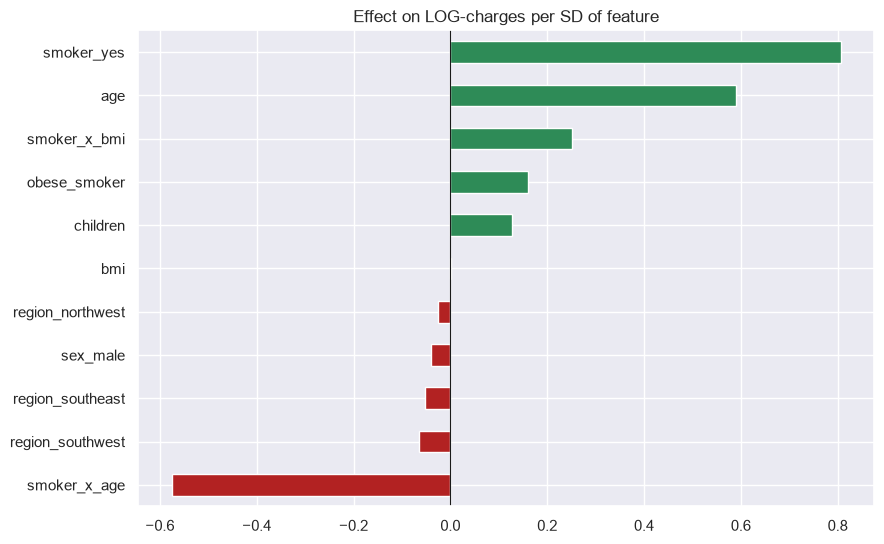

,smoker_yes,age,smoker_x_age,smoker_x_bmi,obese_smoker,children
beta_log,0.806,0.59,-0.576,0.251,0.161,0.127


,avg predicted $,count
smoker,,
no,7835.0,1064
yes,32157.0,274


In [4]:
betas = pd.Series(pipe.named_steps["lr"].coef_,
                  index=feats.columns).sort_values()

plt.figure(figsize=(9, 5.6))
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Effect on LOG-charges per SD of feature")
plt.tight_layout(); plt.show()

top_effects = betas.abs().sort_values(ascending=False).head(6).index
display(betas[top_effects].round(3).to_frame("beta_log").T)

seg = (ins.assign(pred=np.expm1(pipe.predict(feats.values.astype(float))))
          .groupby(["smoker"])["pred"]
          .agg(["mean", "count"]).round(0))
display(seg.rename(columns={"mean": "avg predicted $"}))

## 4. Diagnostics on log-scale residuals

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_59436\2419763850.py:13: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
D:\projects\python\MLCourse\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


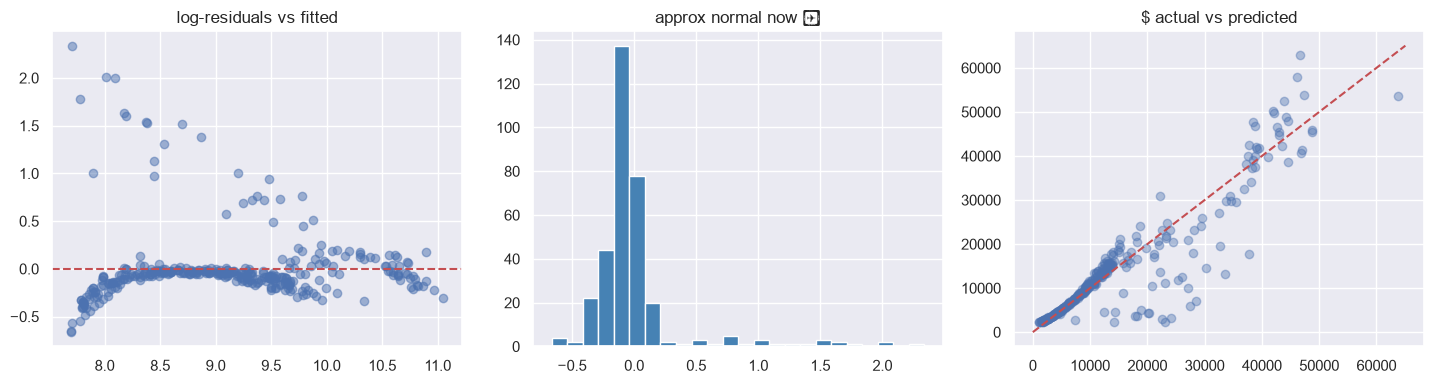

In [5]:
resid_log = ylog_te - pred_log

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4))
axes[0].scatter(pred_log, resid_log, alpha=.5); axes[0].axhline(0, c="r", ls="--")
axes[0].set_title("log-residuals vs fitted")

axes[1].hist(resid_log, bins=24, color="steelblue")
axes[1].set_title("approx normal now ✓")

axes[2].scatter(yraw_te, pred_raw, alpha=.4)
lims = [0, max(yraw_te.max(), pred_raw.max())*1.02]
axes[2].plot(lims, lims, "r--"); axes[2].set_title("$ actual vs predicted")
plt.tight_layout(); plt.show()
# Remaining right-tail misses: catastrophic-cost outliers no linear model catches.

## Findings & recommendations

1. **Smoking is THE cost driver**: base effect ≈ ×1.9 on charges; the
   smoker×bmi interaction adds a steep surcharge for obese smokers.
2. Age raises costs steadily for everyone, but ~+4%/yr faster for smokers
   (interaction coefficient).
3. Log-target was essential: raw-charge fits chase outliers and fail R² badly;
   log-space errors are near-Gaussian.
4. Region/sex contribute little after controls - pricing models should not
   lean on them (fairness bonus).
5. Median-$ error lands around ~$900-1100; tail cases need a separate
   high-risk triage model (trees/GLMs later in the track).

### Limitations
- n=1338 snapshot; no claims history/comorbidities.
- Linear model underprices extreme tails by construction.

## Summary & key takeaways

- Web data → cache pattern keeps notebooks offline-friendly.
- EDA SPOTTED the interactions we then engineered - always look first.
- log1p target transforms an ugly skewed regression into a well-behaved one;
  report metrics back in dollars via expm1.